# 第四章：数据探索与实验设计 (EDA)

##  数据概况与基本统计
本节主要探究：
1. 样本划分与基本规模检查（训练集、拒绝集）。
2. 目标变量 `y` (是否违约) 的总体违约率及占比分布。
3. 真实业务的核心痛点 —— 标签 `profit` (实际收益) 的极度长尾分布。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 忽略警告，设置 Mac 适用的中文字体（确保画图时中文不乱码）
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False 

# 设置 Seaborn 风格（让图表更有论文的学术感）
sns.set_theme(style="whitegrid", font="Arial Unicode MS", font_scale=1.1)

# 数据集路径设定
DATA_DIR = '../data/raw/' 
TRAIN_PATH = DATA_DIR + 'train.xlsx'
REJ_PATH = DATA_DIR + 'rej.xlsx'
TEST_PATH = DATA_DIR + 'test.xlsx'


print("正在读取 Excel 数据...")
df_train = pd.concat([pd.read_excel(TRAIN_PATH), pd.read_excel(TEST_PATH)], ignore_index=True)
df_rej = pd.read_excel(REJ_PATH)
print("✅ 数据加载完成！")

正在读取 Excel 数据...
✅ 数据加载完成！


In [ ]:
# 1. 样本规模概况查看
def get_shape_info(df):
    """获取样本数量以及以 'x' 开头的特征数量。

    Args:
        df: pd.DataFrame, 目标数据集。

    Returns:
        tuple: 包含两个整数的元组，分别为 (样本数量, 以 'x' 开头的特征数量)。
    """
    n_samples = df.shape[0]
    n_features = sum(str(col).startswith('x') for col in df.columns)
    return (n_samples, n_features)

data_shapes = {
    "接受集(Train)": get_shape_info(df_train),
    "拒绝集(Reject)": get_shape_info(df_rej)
}

shape_df = pd.DataFrame(data_shapes, index=['样本数量(行)', '特征数量(列)']).T
print("=== 数据集规模概况 ===")
display(shape_df)

print("\n=== 训练集特征数据类型概况 ===")
print(df_train.dtypes.value_counts())




=== 数据集规模概况 ===


,样本数量(行),特征数量(列)
接受集(Train),25347,123
拒绝集(Reject),19364,123



=== 训练集特征数据类型概况 ===
float64    75
int64      53
object      1
Name: count, dtype: int64


In [12]:
# 2. 不同产品 目标变量 y (违约标签)/profit 分布

def get_product_metrics(df_train, df_rej=None):
    """按照不同产品 (pname) 计算违约率、收益均值与收益标准差，以及训练集/拒绝集样本量。

    Args:
        df_train: pd.DataFrame, 训练集（接受集）。应包含 'pname' 列，以及 'y', 'profit' 列。
        df_rej:   pd.DataFrame, 拒绝集（可选）。应包含 'pname' 列。

    Returns:
        pd.DataFrame: 不同产品的统计指标展示表。若存在计算为空（NaN）的数据，输出为 0。
    """
    if 'pname' not in df_train.columns:
        print("数据集中未找到 'pname' 列。")
        return pd.DataFrame()

    def calc_metrics(group):
        """对单个产品分组计算评估指标。"""
        metrics = {}

        # 1. 计算违约率 y_mean
        if 'y' in group.columns:
            metrics['违约率(y_mean)'] = group['y'].mean()

        # 2. 计算 profit 的均值和标准差
        if 'profit' in group.columns:
            metrics['收益均值(profit_mean)'] = group['profit'].mean()
            metrics['收益标准差(profit_std)'] = group['profit'].std()

        return pd.Series(metrics)

    # 按照 pname 进行分组计算
    metrics_df = df_train.groupby('pname').apply(calc_metrics)
    metrics_df = metrics_df.fillna(0)

    # 3. 添加训练集样本数量
    train_counts = df_train.groupby('pname').size().rename('训练集样本数')
    metrics_df = metrics_df.join(train_counts)

    # 4. 添加拒绝集样本数量
    if df_rej is not None and 'pname' in df_rej.columns:
        rej_counts = df_rej.groupby('pname').size().rename('拒绝集样本数')
        metrics_df = metrics_df.join(rej_counts, how='left')
        metrics_df['拒绝集样本数'] = metrics_df['拒绝集样本数'].fillna(0).astype(int)
    else:
        metrics_df['拒绝集样本数'] = 0

    return metrics_df

print("=== 不同产品指标概况 ===")
train_product_metrics = get_product_metrics(df_train, df_rej)
display(train_product_metrics)


=== 不同产品指标概况 ===


,违约率(y_mean),收益均值(profit_mean),收益标准差(profit_std),训练集样本数,拒绝集样本数
pname,,,,,
p1,0.096649,-6.347792,3044.88101,10802,19364
p2,0.099808,0.000000,0.00000,4158,0
p3,0.099513,0.000000,0.00000,4110,0
p4,0.100320,0.000000,0.00000,4057,0
p5,0.109459,-42.646626,2254.59394,2220,0


In [9]:
# 3.pname = 'p1'的样本概况

def filter_pname(df, pname='p1'):
    """保留指定产品名称 (pname) 的数据副本。

    Args:
        df: pd.DataFrame, 需要过滤的数据框。
        pname: str, 需要筛选保留的产品名称，默认为 'p1'。

    Returns:
        pd.DataFrame: 筛选后的数据框副本。如果不存在 'pname' 列，则返回原数据框。
    """
    if 'pname' in df.columns:
        return df[df['pname'] == pname].copy()
    else:
        print("注意: 数据集中未发现 'pname' 列，按原样返回。")
        return df

print(f"正在将全局数据集过滤为仅包含 pname='p1' 的样本...")

# 将全局数据集替换为只含 p1 的子集
df_train = filter_pname(df_train, 'p1')
df_rej = filter_pname(df_rej, 'p1')

# 由于 df_oot 可能是按需读入的，所以使用 globals / locals 检查是否存在后再处理
if 'df_oot' in globals() or 'df_oot' in locals():
    df_oot = filter_pname(df_oot, 'p1')

# 重新复用之前的 get_shape_info 列出最新数据集的探查概况
data_shapes_p1 = {
    "接受集(Train) [p1]": get_shape_info(df_train),
    "拒绝集(Reject) [p1]": get_shape_info(df_rej)
}

if 'df_oot' in globals() or 'df_oot' in locals():
    data_shapes_p1["跨期测试集(OOT) [p1]"] = get_shape_info(df_oot)

shape_df_p1 = pd.DataFrame(data_shapes_p1, index=['样本数量(行)', '特征数量(列)']).T
print("\n=== 本次分析数据集规模概况 (pname='p1') ===")
display(shape_df_p1)


正在将全局数据集过滤为仅包含 pname='p1' 的样本...

=== 本次分析数据集规模概况 (pname='p1') ===


,样本数量(行),特征数量(列)
接受集(Train) [p1],10802,123
拒绝集(Reject) [p1],19364,123


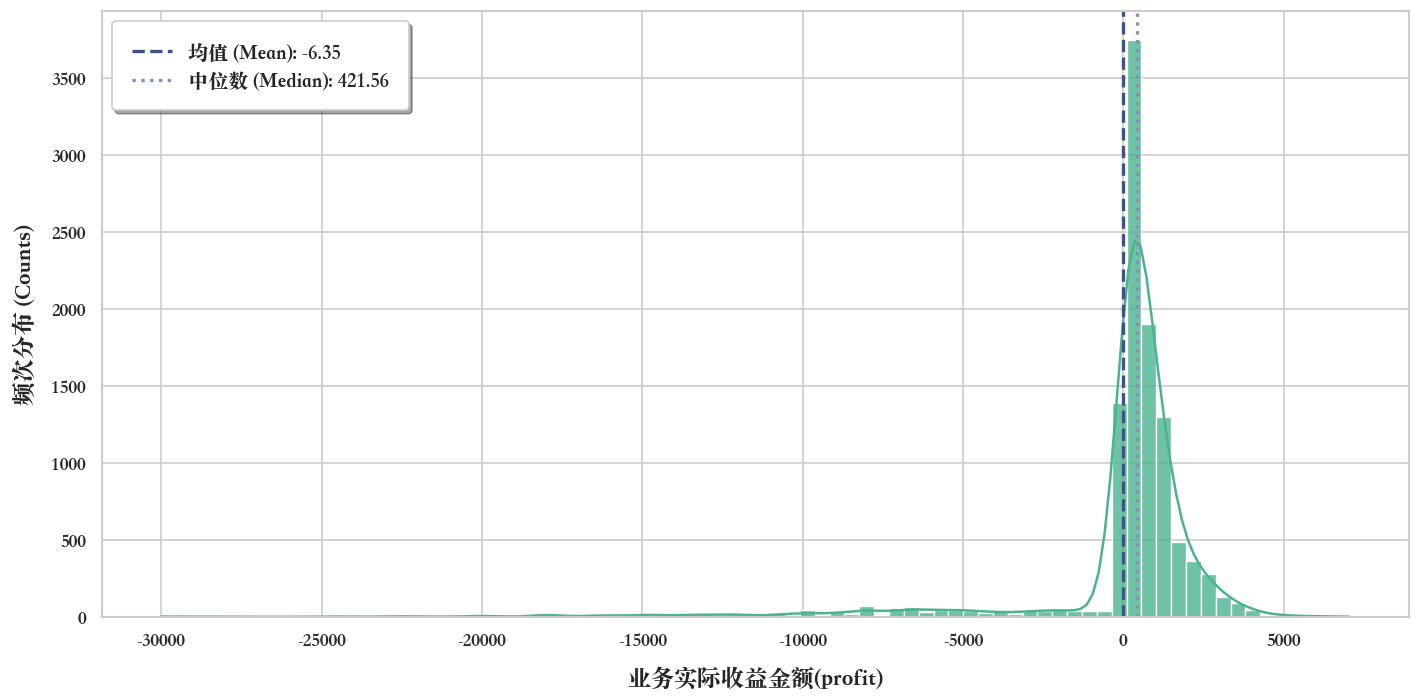

In [22]:
# 查看新数据集profit分布情况

import matplotlib.pyplot as plt
import seaborn as sns

def plot_profit_distribution(df, col_name='profit', p_name=None):
    """绘制实际收益 (profit) 的数据分布图，包含直方图、KDE 和关键基准线。

    Args:
        df: pd.DataFrame, 必须包含用于计算分布的数值列。
        col_name: str, 需要绘图的数值列名称，默认为 'profit'。
        p_name: str, 可选，按 p_name 列过滤产品，默认为 None（不过滤）。

    Returns:
        None, 直接渲染并在输出区显示对应的图表。
    """
    if p_name is not None:
        df = df[df['pname'] == p_name]

    if df is None or df.empty or col_name not in df.columns:
        print(f"数据集中未发现 '{col_name}' 列或数据为空，无法绘制。")
        return

    valid_data = df[col_name].dropna()
    if len(valid_data) == 0:
        return

    # 1. 设置底层网格样式
    sns.set_theme(style="whitegrid")
    
    # 2. 核心修正：配置全局系列为衬线体(Serif)，并将宋体放首位！
    # Mac 的 Songti SC 英文字本来就是标准新罗马风。找不到 Songti SC 才会去退化找 SimSun。
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
    plt.rcParams['font.sans-serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
    plt.rcParams['axes.unicode_minus'] = False 
    
    # 启用高清画板
    plt.figure(figsize=(12, 6), dpi=120)
    
    # 绘制带 kde 曲面的分箱直方图
    ax = sns.histplot(
        valid_data,
        bins=80,
        kde=True,              
        color='#4CB391',
        edgecolor='white',
        linewidth=0.8,
        alpha=0.8
    )
    
    # 计算核心统计指标
    mean_val = valid_data.mean()
    median_val = valid_data.median()
    
    # 增加分隔线并带有图例说明
    # plt.axvline(0, color='#E64B35', linestyle='-', linewidth=2.5, label='盈亏平衡线 (Profit=0)')
    plt.axvline(mean_val, color='#3C5488', linestyle='--', linewidth=2, label=f'均值 (Mean): {mean_val:.2f}')
    plt.axvline(median_val, color='#8491B4', linestyle=':', linewidth=2, label=f'中位数 (Median): {median_val:.2f}')
    
    # 标题：若指定了产品则显示产品名
    # title = f"接受集 (p_name='{p_name}') 实际收益 (Profit) 分布" if p_name else "实际收益 (Profit) 分布"
    # plt.title(title, fontsize=16, pad=15, fontweight='bold')
    plt.xlabel('业务实际收益金额(profit)', fontsize=14, labelpad=10)
    plt.ylabel('频次分布 (Counts)', fontsize=14, labelpad=10)
    
    plt.legend(fontsize=12, frameon=True, shadow=True, borderpad=1)
    
    plt.tight_layout()
    plt.show()

# 出图（只看 p1 产品）
plot_profit_distribution(df_train, 'profit', p_name='p1')


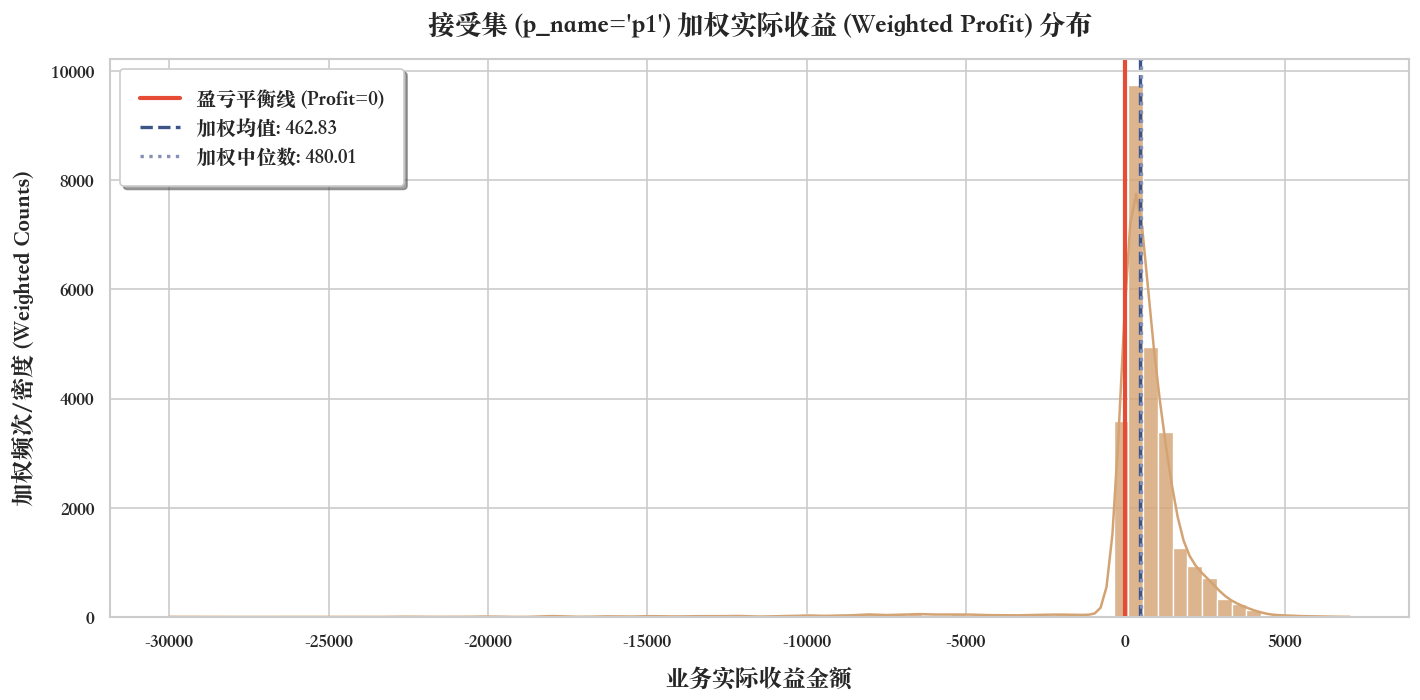

In [ ]:
# 4.基于w加权后的profit分布

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_weighted_profit_distribution(df, col_name='profit', weight_col='w'):
    """绘制基于权重 (w) 加权后的实际收益 (profit) 数据分布图。

    此时的频次与统计指标均考虑样本权重，反映真实的业务损失与收益占比。
    
    Args:
        df: pd.DataFrame, 必须包含数值列和权重列。
        col_name: str, 需要绘图的数值列名称，默认为 'profit'。
        weight_col: str, 权重列名称，默认为 'w'。

    Returns:
        None, 直接渲染图表。
    """
    if df is None or df.empty or col_name not in df.columns or weight_col not in df.columns:
        print(f"数据集中未发现 '{col_name}' 或 '{weight_col}' 列，无法绘制加权分布。")
        return

    # 提取所需数据并去除空值
    valid_data = df[[col_name, weight_col]].dropna()
    if len(valid_data) == 0:
        return

    # 设置学术网格与字体（双拼兼容 Mac 宋体与新罗马）
    sns.set_theme(style="whitegrid")
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
    plt.rcParams['font.sans-serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
    plt.rcParams['axes.unicode_minus'] = False 
    
    # ---------------- 严谨的加权统计计算 ----------------
    weight_sum = valid_data[weight_col].sum()
    if weight_sum > 0:
        # 1. 计算加权均值: sum(profit * w) / sum(w)
        weighted_mean = (valid_data[col_name] * valid_data[weight_col]).sum() / weight_sum
        
        # 2. 计算加权中位数: 排序后寻找累计权重恰好突破总权重 50% 处的值
        df_sorted = valid_data.sort_values(col_name)
        cumsum = df_sorted[weight_col].cumsum()
        cutoff = weight_sum / 2.0
        weighted_median = df_sorted[cumsum >= cutoff][col_name].iloc[0]
    else:
        weighted_mean = valid_data[col_name].mean()
        weighted_median = valid_data[col_name].median()
        
    # ---------------- 核心绘图区 ----------------
    plt.figure(figsize=(12, 6), dpi=120)
    
    # seaborn histplot 支持 weights 参数进行加权处理
    ax = sns.histplot(
        data=valid_data,
        x=col_name,
        weights=weight_col,
        bins=80,
        kde=True,              
        color='#D4A373',       # 换用优雅的大地色系加以区分
        edgecolor='white',
        linewidth=0.8,
        alpha=0.8
    )
    
    # 增设各类基准线
    # plt.axvline(0, color='#E64B35', linestyle='-', linewidth=2.5, label='盈亏平衡线 (Profit=0)')
    plt.axvline(weighted_mean, color='#3C5488', linestyle='--', linewidth=2, label=f'加权均值: {weighted_mean:.2f}')
    plt.axvline(weighted_median, color='#8491B4', linestyle=':', linewidth=2, label=f'加权中位数: {weighted_median:.2f}')
    
    # 标签配置
    plt.title("接受集 (p_name='p1') 加权实际收益 (Weighted Profit) 分布", fontsize=16, pad=15, fontweight='bold')
    plt.xlabel('业务实际收益金额', fontsize=14, labelpad=10)
    plt.ylabel('加权频次/密度 (Weighted Counts)', fontsize=14, labelpad=10)
    
    plt.legend(fontsize=12, frameon=True, shadow=True, borderpad=1)
    
    plt.tight_layout()
    plt.show()

# 绘制 df_train 加权图
plot_weighted_profit_distribution(df_train, col_name='profit', weight_col='w')


## 拒绝样本分布偏差验证

正在计算特征分布差异，寻找分布重合度最低的代表性特征...
✅ 筛选出三大显著“峰位偏移”的特征：['x72', 'x74', 'x73']


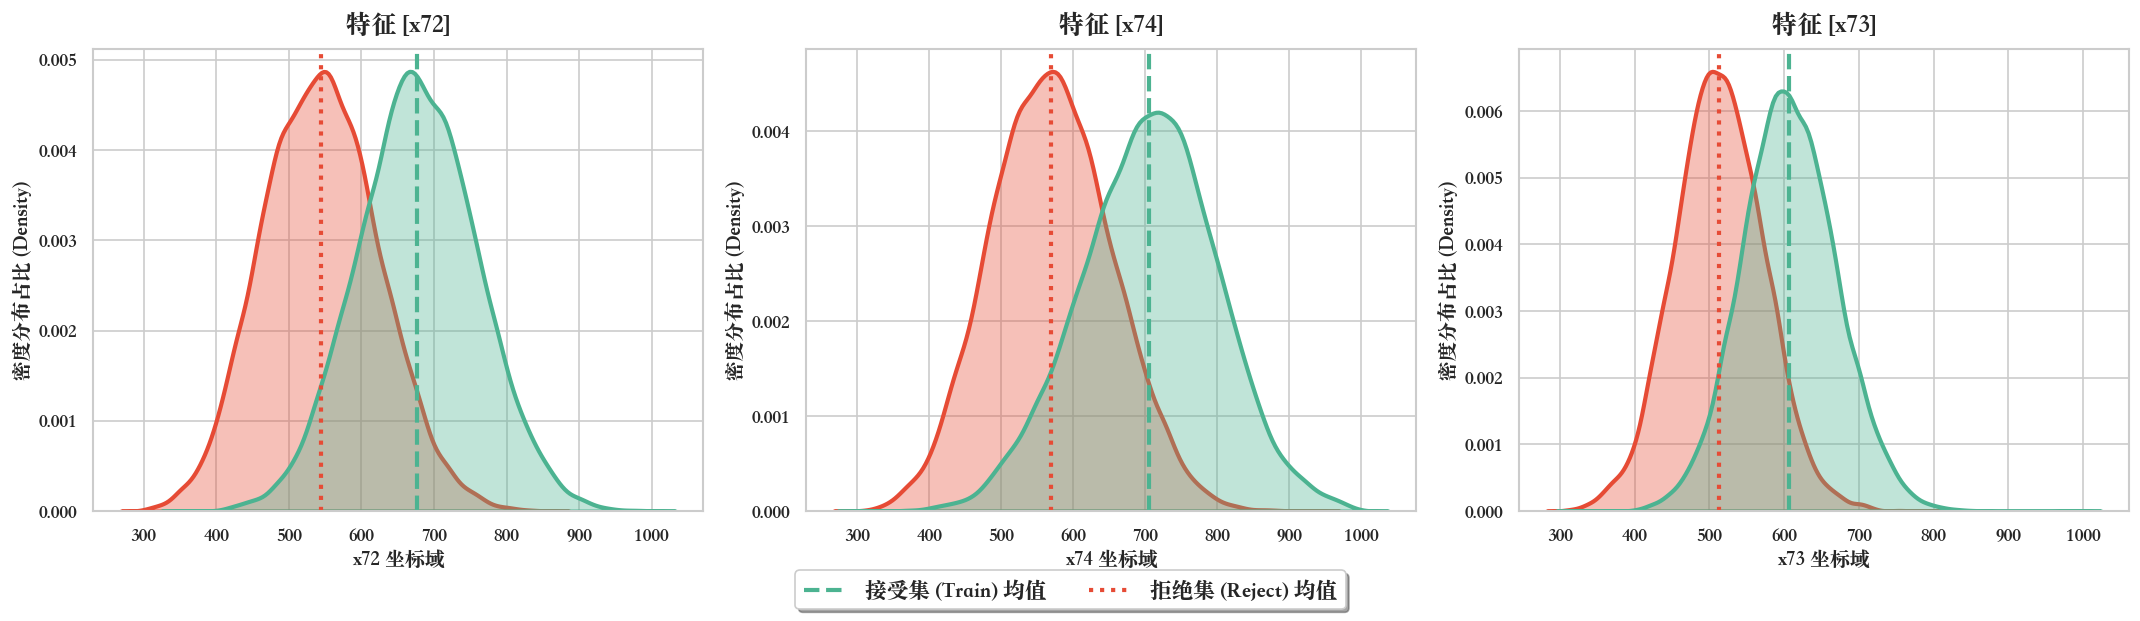

In [8]:
# 关键特征分布对比
# ==========================================
# 4.2.2 接受集与拒绝集关键特征分布对比 (KDE)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import ks_2samp
import matplotlib.lines as mlines

# --- 1. 挑选 3 个最具代表性的特征 ---
# 业务逻辑：通过 KS 检验找出两类人群中分布差异（离散跨度）最大、重叠最少的 3 个核心特征
# 这可以最完美地展示两类客群在特征空间上的“峰位偏移”情况

def get_top_diff_features(df_a, df_b, prefix='x', top_n=3):
    """自动计算并筛选两个数据集中分布差异最大的关键特征"""
    features = [col for col in df_a.columns if str(col).startswith(prefix) and col in df_b.columns]
    
    diff_scores = []
    for f in features:
        data_a = df_a[f].dropna()
        data_b = df_b[f].dropna()
        if len(data_a) == 0 or len(data_b) == 0:
            continue
        # 计算 KS 统计量(越大说明重叠度越低，分布差异越显著)
        stat, _ = ks_2samp(data_a, data_b)
        diff_scores.append((f, stat))
        
    # 按照统计差异量从大到小排序
    diff_scores.sort(key=lambda x: x[1], reverse=True)
    return [item[0] for item in diff_scores[:top_n]]

print("正在计算特征分布差异，寻找分布重合度最低的代表性特征...")
top_3_features = get_top_diff_features(df_train, df_rej, prefix='x', top_n=3)
print(f"✅ 筛选出三大显著“峰位偏移”的特征：{top_3_features}")


# --- 2. 绘制 KDE 分布对比图 ---
def plot_kde_comparison(df1, df2, features, label1='接受集 (Train)', label2='拒绝集 (Reject)'):
    """绘制多个特征的 KDE 密度对比分布图"""
    
    # 设置底部作图风格和字体（适配 MacOS 中文及学术论文衬线体要求）
    sns.set_theme(style="whitegrid")
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
    plt.rcParams['font.sans-serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
    plt.rcParams['axes.unicode_minus'] = False 
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)
    # fig.suptitle("接受集与拒绝集在核心特征上的分布对比：显著峰位偏移与重叠缺失", fontsize=18, fontweight='bold', y=1.05)
    
    # 定义对比所用颜色
    colors = {label1: '#4CB391', label2: '#E64B35'}
    
    for i, feature in enumerate(features):
        ax = axes[i]
        
        # 将两份数据拼接到长表中，方便 Seaborn 使用 Hue 独立画图
        tmp_df1 = df1[[feature]].copy()
        tmp_df1['数据集'] = label1
        
        tmp_df2 = df2[[feature]].copy()
        tmp_df2['数据集'] = label2
        
        plot_df = pd.concat([tmp_df1, tmp_df2], ignore_index=True)
        
        # 1. KDE 曲线与阴影
        # *注意*：common_norm=False 保证两者面积均为1独立计算密度，精准反应自身峰值真实位置
        sns.kdeplot(
            data=plot_df, 
            x=feature, 
            hue='数据集', 
            fill=True, 
            linewidth=2.5,
            palette=colors,
            alpha=0.35, # 避免重叠处看不清，加上一定透明度
            ax=ax,
            common_norm=False 
        )
        
        # 2. 计算两条中心线以高亮“均值峰位偏移”
        mean_1 = tmp_df1[feature].mean()
        mean_2 = tmp_df2[feature].mean()
        
        ax.axvline(mean_1, color=colors[label1], linestyle='--', linewidth=2.5)
        ax.axvline(mean_2, color=colors[label2], linestyle=':', linewidth=2.5)
        
        # 定制轴文本格式
        ax.set_title(f'特征 [{feature}]', fontsize=15, pad=10)
        ax.set_xlabel(f'{feature} 坐标域', fontsize=12)
        ax.set_ylabel('密度分布占比 (Density)', fontsize=12)
        
        # 移除子图内部默认的局促图例
        if ax.get_legend() is not None:
            ax.get_legend().remove()
            
    # 从最后一个坐标轴提取原有 KDE 色块标识作为全局图例句柄
    handles, labels = axes[-1].get_legend_handles_labels()
    
    # 将刚刚新增的参考均值线说明加入全局控制图例中
    line_train = mlines.Line2D([], [], color=colors[label1], linestyle='--', linewidth=2.5, label=f'{label1} 均值')
    line_rej = mlines.Line2D([], [], color=colors[label2], linestyle=':', linewidth=2.5, label=f'{label2} 均值')
    
    handles.extend([line_train, line_rej])
    labels.extend([f'{label1} 均值', f'{label2} 均值'])
    
    # 在 3 张图底侧留白处统一存放一条超长图例条
    fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), fontsize=13, frameon=True, shadow=True)

    plt.tight_layout()
    plt.show()

# 运行绘制图表
plot_kde_comparison(df_train, df_rej, top_3_features)



正在读取 IV 值评估结果...
✅ 成功从 IV 值排名前 20 的高价值特征库中，随机抽取以下九大展示特征：
['x13', 'x77', 'x34', 'x81', 'x78', 'x33', 'x93', 'x76', 'x86']


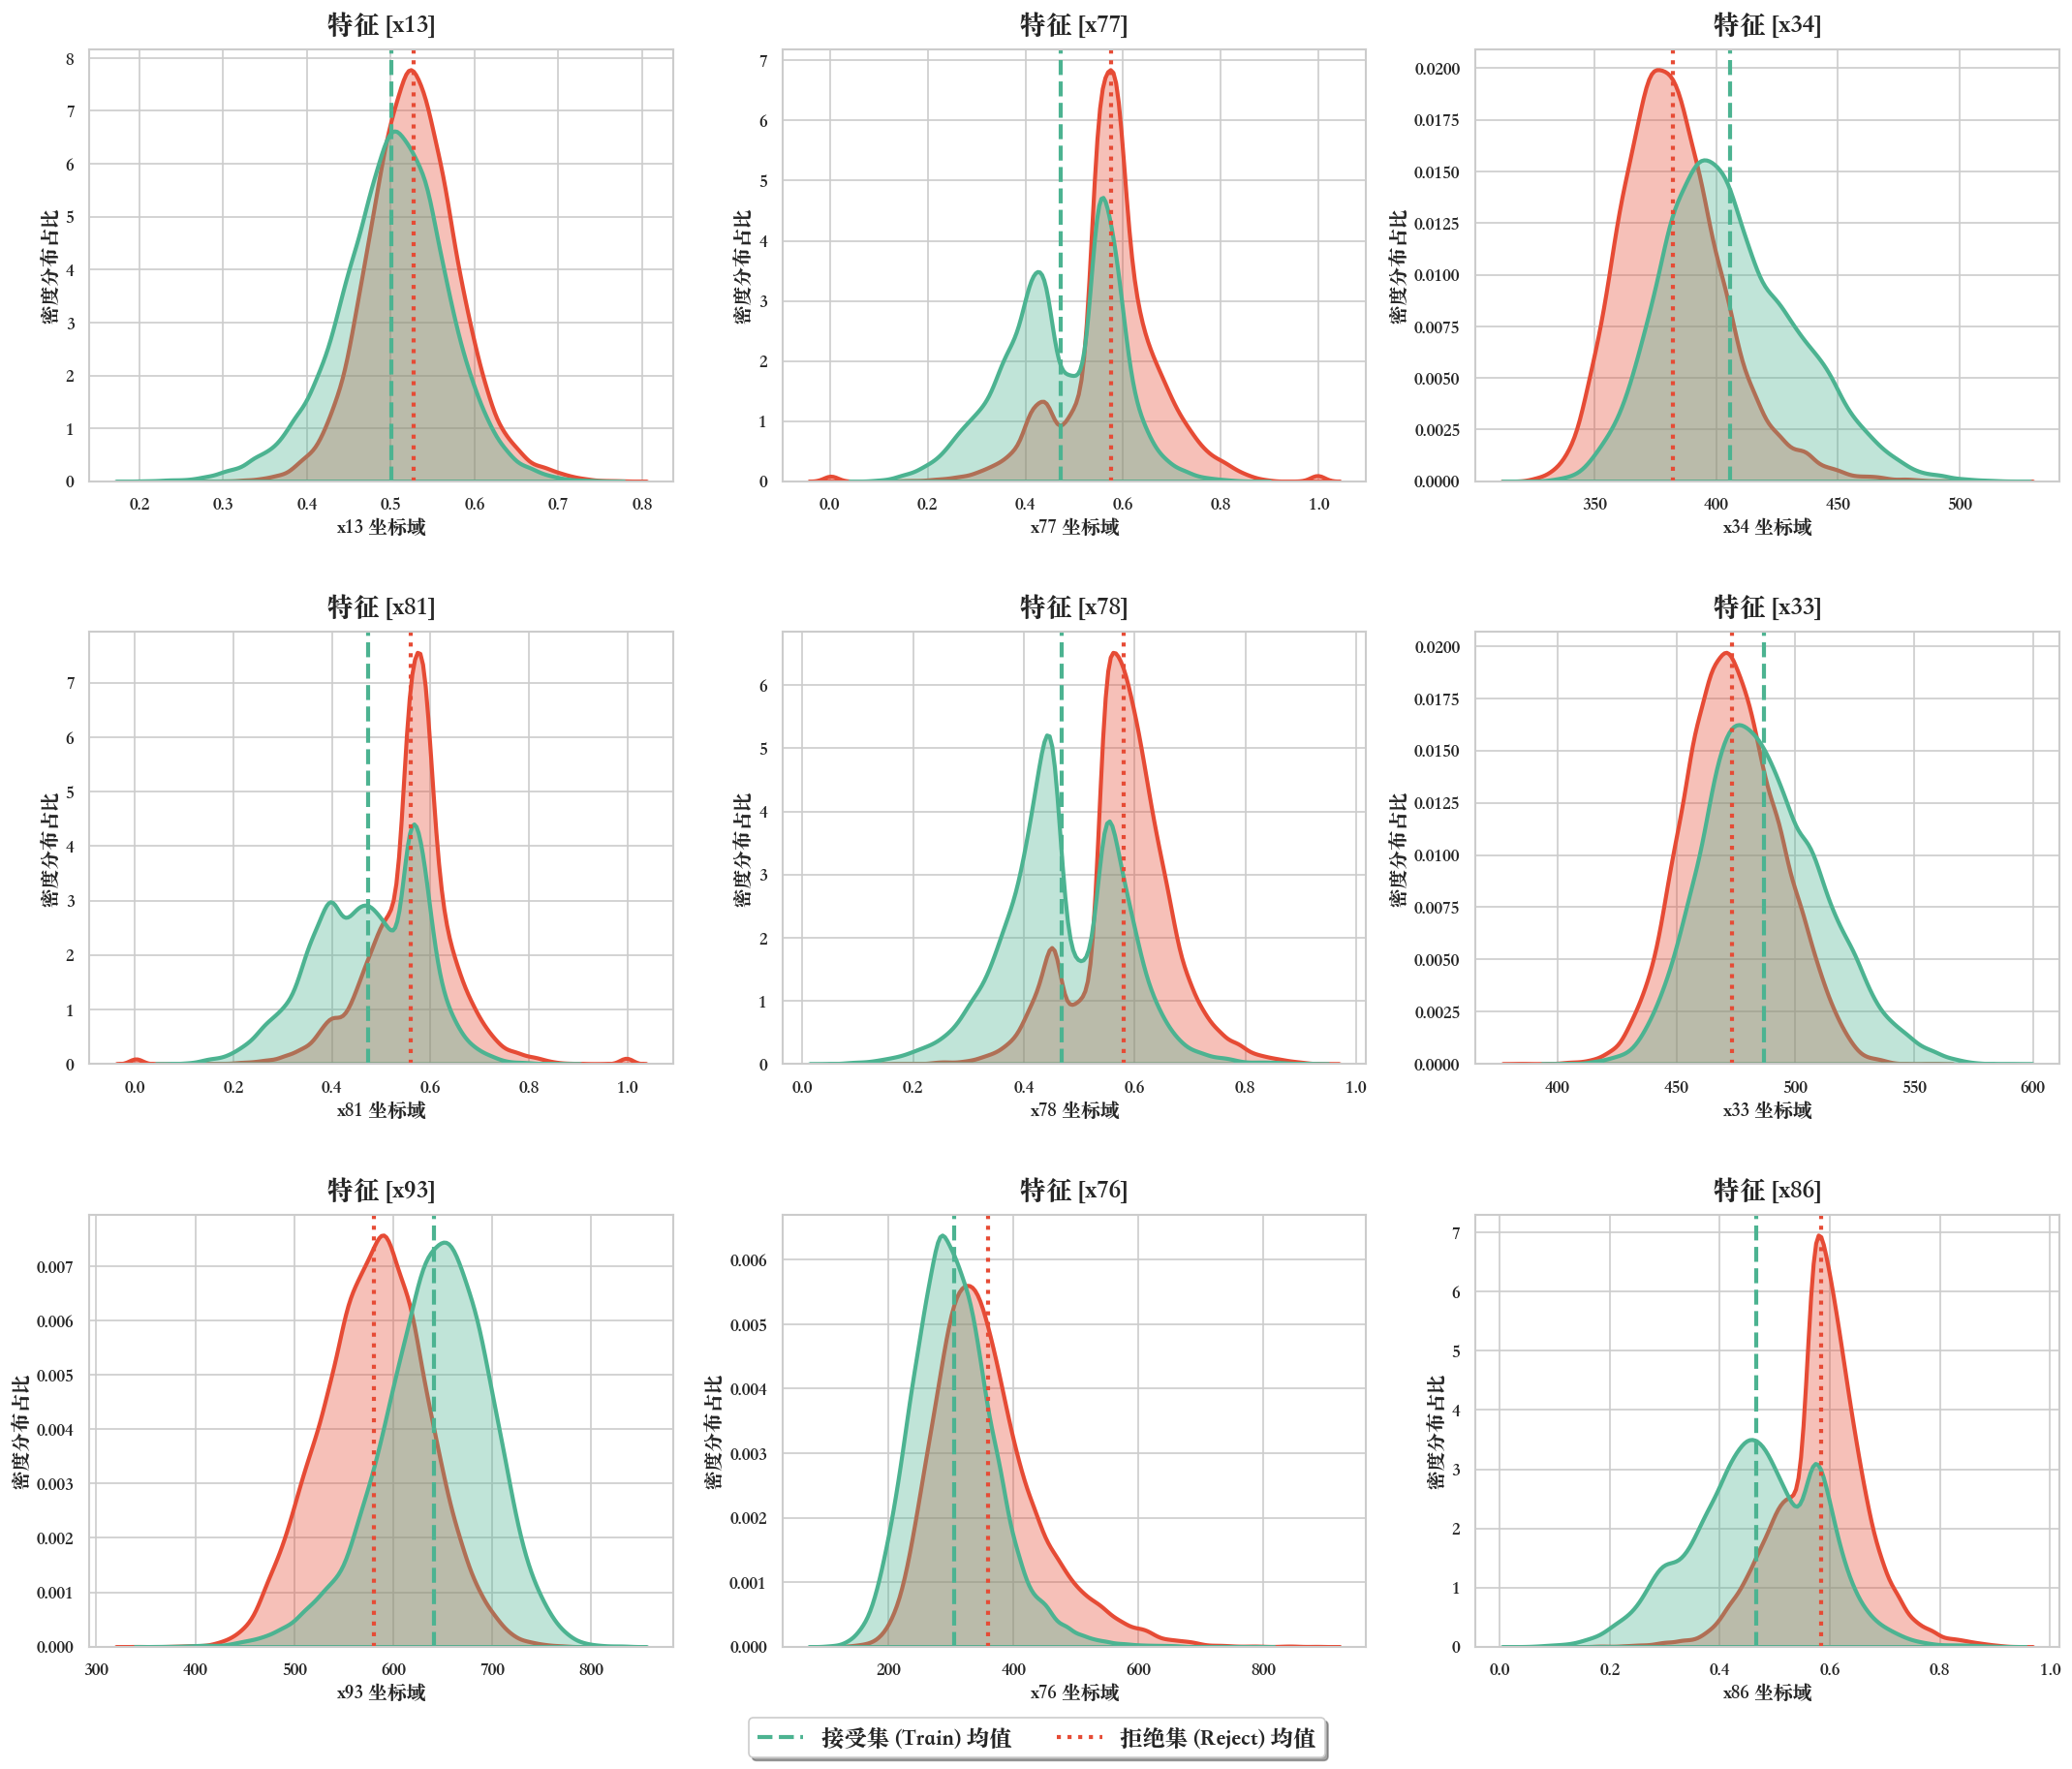

In [4]:
# ==========================================
# 4.2.2 接受集与拒绝集关键特征分布对比 (KDE 3x3)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.lines as mlines
import random
import math

# --- 1. 读取 IV 值，并从 Top 20 中随机挑选 9 个最具代表性的特征 ---
print("正在读取 IV 值评估结果...")
iv_df = pd.read_excel('../data/processed/iv_results.xlsx')

# 按照 iv 值降序排序，提取区分能力最强的 Top 20 特征池
iv_df = iv_df.sort_values(by='iv', ascending=False).reset_index(drop=True)
top_20_features = iv_df['variable'].head(20).tolist()

# 设置一个随机种子（如果你希望每次随机的都是一样的，可以取消下一行的注释）
# random.seed(42)

# 从 Top 20 中随机无放回地抽取 9 个特征用于画 3x3 网格图
top_9_features = random.sample(top_20_features, 9)

print(f"✅ 成功从 IV 值排名前 20 的高价值特征库中，随机抽取以下九大展示特征：\n{top_9_features}")


# --- 2. 绘制 3x3 KDE 分布对比图 ---
def plot_kde_comparison_3x3(df1, df2, features, label1='接受集 (Train)', label2='拒绝集 (Reject)'):
    """绘制 3x3 布局矩阵的 KDE 密度对比分布图"""
    
    # 确保所选特征在当前样本切片中存在
    valid_features = [f for f in features if f in df1.columns and f in df2.columns]
    if not valid_features:
        print("未在当前数据集中找到提供的特征列，请检查数据。")
        return
        
    # 设置作图风格和字体（适配 MacOS 中文及学术论文要求）
    sns.set_theme(style="whitegrid")
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
    plt.rcParams['font.sans-serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
    plt.rcParams['axes.unicode_minus'] = False 
    
    # 动态适应行列：规定 3 列，算出需要的行数 (这里为3)
    cols = 3
    rows = math.ceil(len(valid_features) / cols)
    
    # 画板高度随行数适配放大 (每行给 5 的高度)
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), dpi=120)
    
    # 如果是多维网格，将其拉平成一位数组方便线性循环画图
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
        
    # fig.suptitle("接受集与拒绝集在核心特征上的分布矩阵：显著峰位偏移与重叠缺失", fontsize=21, fontweight='bold', y=1.02)
    
    colors = {label1: '#4CB391', label2: '#E64B35'}
    
    for i in range(len(axes)):
        ax = axes[i]
        
        # 只在实际抽取到的特征数内作图
        if i < len(valid_features):
            feature = valid_features[i]
            
            tmp_df1 = df1[[feature]].copy()
            tmp_df1['数据集'] = label1
            
            tmp_df2 = df2[[feature]].copy()
            tmp_df2['数据集'] = label2
            
            plot_df = pd.concat([tmp_df1, tmp_df2], ignore_index=True)
            
            # KDE 曲线与阴影
            sns.kdeplot(
                data=plot_df, 
                x=feature, 
                hue='数据集', 
                fill=True, 
                linewidth=2.5,
                palette=colors,
                alpha=0.35, 
                ax=ax,
                common_norm=False 
            )
            
            # 计算并标记中心线“均值峰位偏移”情况
            mean_1 = tmp_df1[feature].mean()
            mean_2 = tmp_df2[feature].mean()
            
            ax.axvline(mean_1, color=colors[label1], linestyle='--', linewidth=2.5)
            ax.axvline(mean_2, color=colors[label2], linestyle=':', linewidth=2.5)
            
            ax.set_title(f'特征 [{feature}]', fontsize=16, pad=10)
            ax.set_xlabel(f'{feature} 坐标域', fontsize=12)
            ax.set_ylabel('密度分布占比', fontsize=12)
            
            # 移除每个子图自带零散的图例
            if ax.get_legend() is not None:
                ax.get_legend().remove()
        
        else:
            # 如果抽取的特征数不足 9 个（网格空余），隐藏多余的边框和轴线
            ax.axis('off')
            
    # 从图解矩阵的第 1 个子图提取统一的全局 KDE 图例句柄
    handles, labels = axes[0].get_legend_handles_labels()
    
    # 将纵向的参考均值线条信息加入图例
    line_train = mlines.Line2D([], [], color=colors[label1], linestyle='--', linewidth=2.5, label=f'{label1} 均值')
    line_rej = mlines.Line2D([], [], color=colors[label2], linestyle=':', linewidth=2.5, label=f'{label2} 均值')
    
    handles.extend([line_train, line_rej])
    labels.extend([f'{label1} 均值', f'{label2} 均值'])
    
    # 底部最下面居中呈现全局控制长图例区
    fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02), fontsize=14, frameon=True, shadow=True)

    # h_pad 防止排练多行子图时，上行的横坐标说明和下行的主标题文本重叠
    plt.tight_layout(h_pad=3)
    plt.subplots_adjust(bottom=0.05)
    plt.show()

# 触发画图
plot_kde_comparison_3x3(df_train, df_rej, top_9_features)


正在运用风控统计学量化各特征的最大分离度 KS 与群体稳定性 PSI...


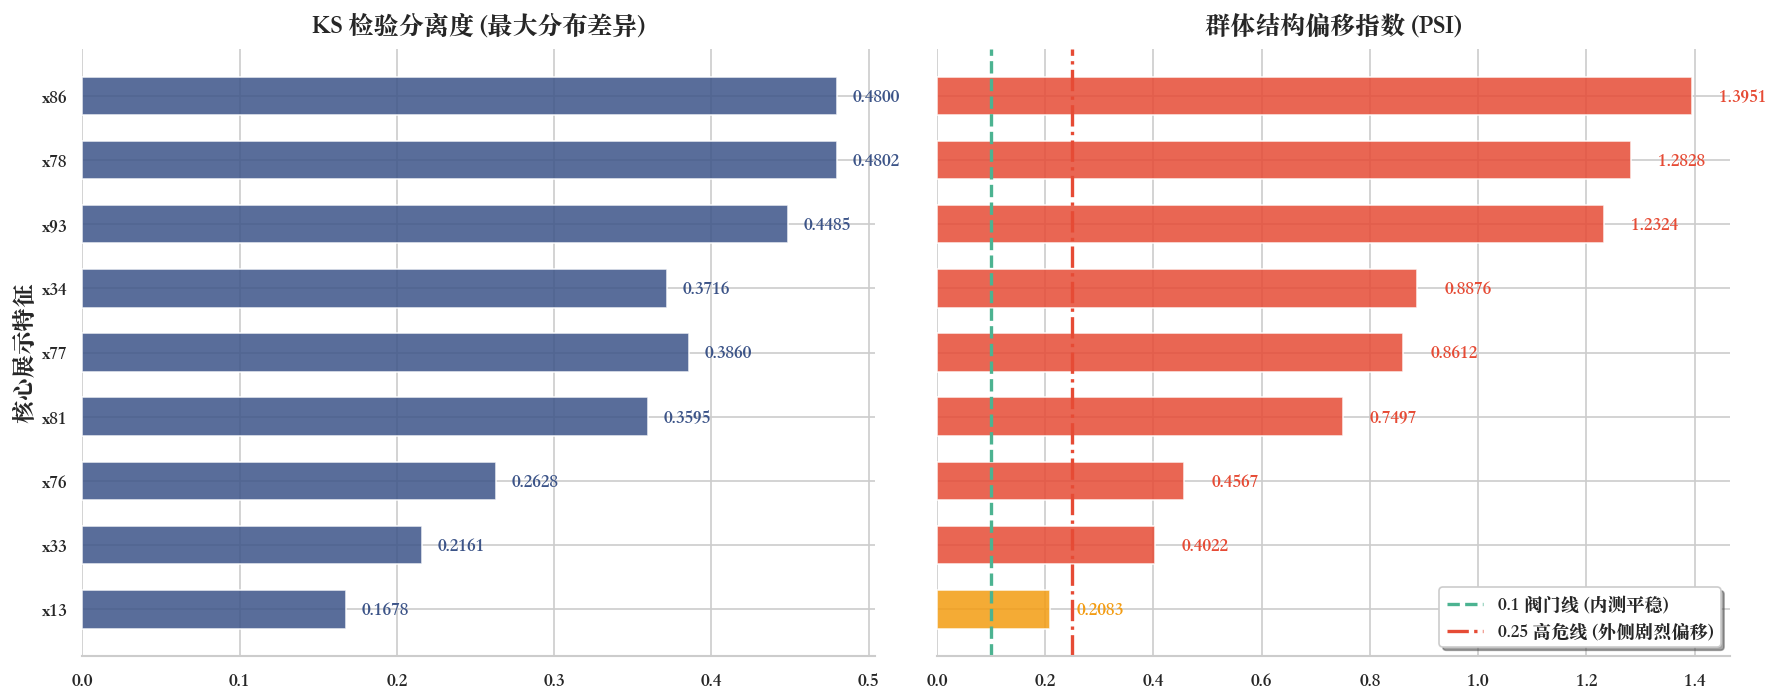

In [5]:
# ==========================================
# 4.2.3 接受集与拒绝集分布偏移量化分析 (PSI & KS)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

# --- 1. 纯净的手写定义 PSI 计算核心函数 ---
def calculate_psi(expected, actual, bins=10):
    """
    计算连续变量的 PSI (Population Stability Index)
    expected: 基准分布（代表接受集 Train）
    actual: 对比群体（代表拒绝集 Reject）
    """
    expected = expected.dropna()
    actual = actual.dropna()
    
    if len(expected) == 0 or len(actual) == 0:
        return np.nan
        
    # 根据接受集 (expected) 的分布规律，使用等频分箱切割 10 段
    try:
        _, bins_edges = pd.qcut(expected, q=bins, retbins=True, duplicates='drop')
    except:
        # 极差分箱退位保底方案
        _, bins_edges = pd.cut(expected, bins=bins, retbins=True)
        
    # 彻底敞开两端边界，避免测试集中存在极值越界
    bins_edges = list(bins_edges)
    bins_edges[0] = -np.inf  
    bins_edges[-1] = np.inf
    
    # 统计两组客群在分箱中落点人数占比频次
    expected_counts, _ = np.histogram(expected, bins=bins_edges)
    actual_counts, _ = np.histogram(actual, bins=bins_edges)
    
    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)
    
    # 规避数学界限问题（防止频数完全为空的分段引发对数底无穷异常）
    expected_perc = np.where(expected_perc == 0, 1e-5, expected_perc)
    actual_perc = np.where(actual_perc == 0, 1e-5, actual_perc)
    
    # PSI 公式映射 : Sum ( (实际占比 - 预期占比) * ln(实际占比 / 预期占比) )
    psi_values = (actual_perc - expected_perc) * np.log(actual_perc / expected_perc)
    return np.sum(psi_values)


# --- 2. 批量计算并映射刚提取的特征群的 KS 和 PSI ---
# 直接沿用上一单元格缓存好的 top_9_features (或 top_3_features)
target_features = top_9_features  

print("正在运用风控统计学量化各特征的最大分离度 KS 与群体稳定性 PSI...")
results = []
for f in target_features:
    if f not in df_train.columns or f not in df_rej.columns: continue
        
    data_train = df_train[f]
    data_rej = df_rej[f]
    
    # 获取 scipy 原生底层的双样本 KS 检验统计值
    ks_stat, _ = ks_2samp(data_train.dropna(), data_rej.dropna())
    # 运转刚刚写好的风控级数 PSI 函数
    psi_val = calculate_psi(data_train, data_rej, bins=10)
    
    # 按风控红绿灯卡尺度动态预分配颜色
    if psi_val >= 0.25:
        risk_color = '#E64B35' # 深红色：严重分布面塌陷
    elif psi_val >= 0.1:
        risk_color = '#F39C12' # 橙黄色：轻中度结构异化
    else:
        risk_color = '#4CB391' # 绿色：群体平稳
        
    results.append({
        'Feature': f,
        'KS_Stat': ks_stat,
        'PSI': psi_val,
        'Color': risk_color
    })

# 构建数据集容器，按 PSI 严重程度排个序，画出来的柱状图就像爬楼梯一样好看
res_df = pd.DataFrame(results).sort_values(by='PSI', ascending=True)

# --- 3. 绘制高级学术双坐标系多维水平条形图展示 ---
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
plt.rcParams['font.sans-serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
plt.rcParams['axes.unicode_minus'] = False 

# 左右双打画板 (sharey=True代表两个子图共用中轴的特征名)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True, dpi=120)
# fig.suptitle("客群差异的显著性量化检验：KS 分离统计量与 PSI 偏移指数剖析", fontsize=18, fontweight='bold', y=1.05)

# -----------------
# 【左侧】KS检验图
# -----------------
ax1.barh(res_df['Feature'], res_df['KS_Stat'], color='#3C5488', alpha=0.85, height=0.6)
ax1.set_title("KS 检验分离度 (最大分布差异)", fontsize=15, pad=10)
# ax1.set_xlabel("Kolmogorov-Smirnov Stat (值越大说明异质性越强)", fontsize=12)
ax1.set_ylabel("核心展示特征", fontsize=14)

# 纯手工逐刻度贴上文字标签，替代生硬坐标轴
for idx, val in enumerate(res_df['KS_Stat']):
    ax1.text(val + 0.01, idx, f"{val:.4f}", va='center', fontsize=11, fontweight='bold', color='#3C5488')

# -----------------
# 【右侧】PSI稳定性图
# -----------------
ax2.barh(res_df['Feature'], res_df['PSI'], color=res_df['Color'], alpha=0.85, height=0.6)
ax2.set_title("群体结构偏移指数 (PSI)", fontsize=15, pad=10)
# ax2.set_xlabel("Population Stability Index (越长说明偏离越严重)", fontsize=12)

# 拉起两根标准的风控辅助参考安全警戒线
ax2.axvline(0.1, color='#4CB391', linestyle='--', linewidth=2, label="0.1 阀门线 (内测平稳)")
ax2.axvline(0.25, color='#E64B35', linestyle='-.', linewidth=2, label="0.25 高危线 (外侧剧烈偏移)")
ax2.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)

for idx, (val, color) in enumerate(zip(res_df['PSI'], res_df['Color'])):
    ax2.text(val + 0.05, idx, f"{val:.4f}", va='center', fontsize=11, fontweight='bold', color=color)

# 移除没必要的上右边界，让学术图有呼吸感
sns.despine(left=True)
plt.tight_layout()
plt.show()


## 决策目标单一的局限：风险与盈利的错位分析

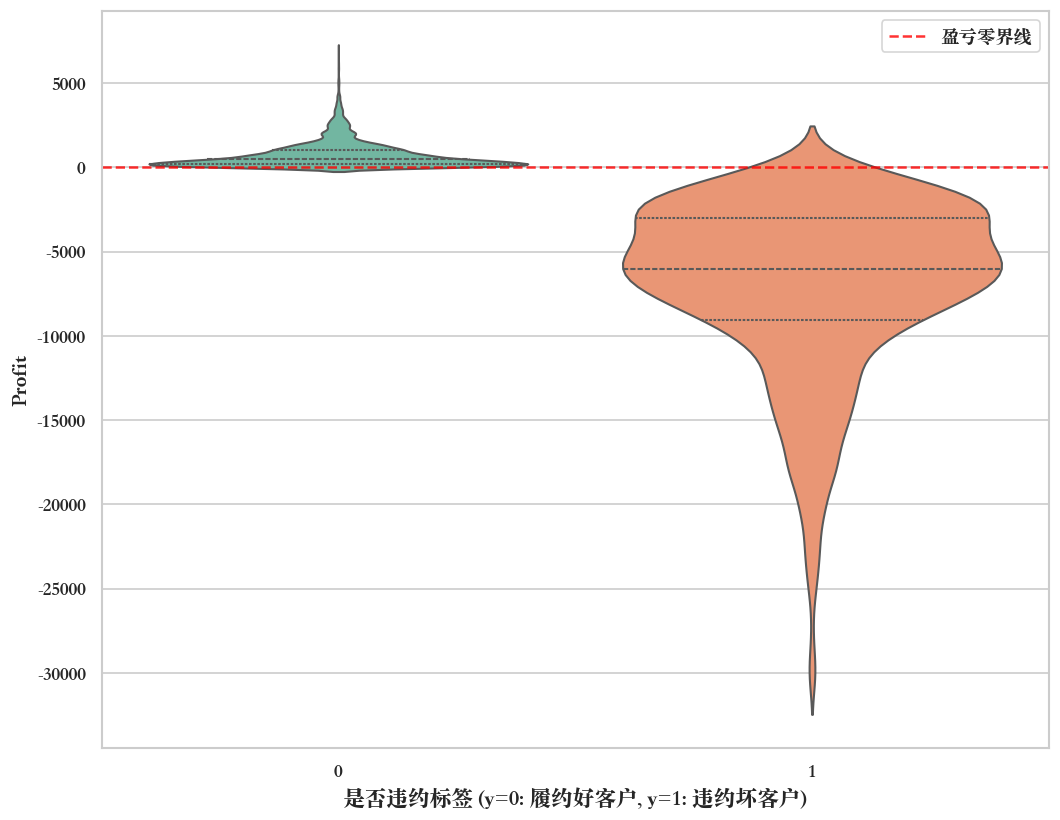

In [6]:
# ==============================================================================
# 图 A：分类数据极差——违约标签对高商业价值差异的绝对掩盖 (Violin Plot)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# 统一样式与论文中文字体
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
plt.rcParams['font.sans-serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

# 获取当前绘图数据，替换为您的实际 DataFrame
df_plot = df_train.copy() 

fig1, ax1 = plt.subplots(figsize=(9, 7), dpi=120)

# 绘制小提琴图，展现方差分布
sns.violinplot(x='y', y='profit', data=df_plot, ax=ax1, inner="quartile", palette="Set2", hue='y', legend=False)
ax1.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label="盈亏零界线")

# ax1.set_title("图 A：分类目标对方差纵贯极致差异的绝对掩盖", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("是否违约标签 (y=0: 履约好客户, y=1: 违约坏客户)", fontsize=13)
ax1.set_ylabel("Profit", fontsize=13)
ax1.legend()

# 增添文本解析标注框
# ax1.text(0.5, ax1.get_ylim()[1]*0.85, 
#          "即使同样是分类目标中的 y=0 优质客群，\n其真实产生的收益跨度也能从几十元跃升至上万元。\n传统的分类交叉熵(BCE)视同阶目标完全相等，\n从数据层面粗暴抹杀了金字塔尖的高价值头部！", 
#          ha='center', va='center', bbox=dict(facecolor='white', alpha=0.9, edgecolor='red'), 
#          fontsize=12, color='darkred')

plt.tight_layout()
plt.show()


“图 X 展示了信贷数据集中客户真实产生的商业收益（Profit）在传统二元分类标签（履约与违约）下的分布情况。由图可见，传统的二分类交叉熵损失（BCE Loss）建立在一个强同质化假设之上，即：视所有归属于同一类别的样本为等阶目标。然而在实际信贷场景中，同为履约客户（$y=0$），其带来的历史真实收益呈现出极宽的重尾分布（方差极大）；个体的商业贡献跨度不仅高达数百倍，甚至存在部分标示为履约却因资金成本等原因导致微亏的样本。这种只辨‘黑白’、不识‘大小’的建模范式，将丰富的纵向价值分布被动地‘拍扁’为了静态的 0-1 标签。这就从数据底层决定了：单纯追求准确率或 AUC 极值的传统风控分类模型，天然丧失了对‘高净值大客’与‘长尾微利低客’的辨识与排序能力，从而成为制约业务利润上限的根本瓶颈。”

## 特征流形空间的可视化探索

正在加载数据 (使用 raw 原始特征构建全域观测面)...
提取到 123 个泛化特征。
开始降维准备：抽取各 3000 条独立样本...
正在进行特征 StandardScaler 标准化...
启动 UMAP 流形学习隐层映射 (保留全局与局部结构，速度远快于 t-SNE)...
UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Mar 24 13:08:40 2026 Construct fuzzy simplicial set
Tue Mar 24 13:08:40 2026 Finding Nearest Neighbors
Tue Mar 24 13:08:40 2026 Building RP forest with 8 trees
Tue Mar 24 13:08:40 2026 NN descent for 12 iterations
	 1  /  12
	 2  /  12
	 3  /  12
	Stopping threshold met -- exiting after 3 iterations
Tue Mar 24 13:08:41 2026 Finished Nearest Neighbor Search
Tue Mar 24 13:08:41 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  13%| █▎         66/500 [00:00]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  93%| █████████▎ 466/500 [00:06]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:06]


Tue Mar 24 13:08:47 2026 Finished embedding
降维完成，开始绘制 2D 散点图...


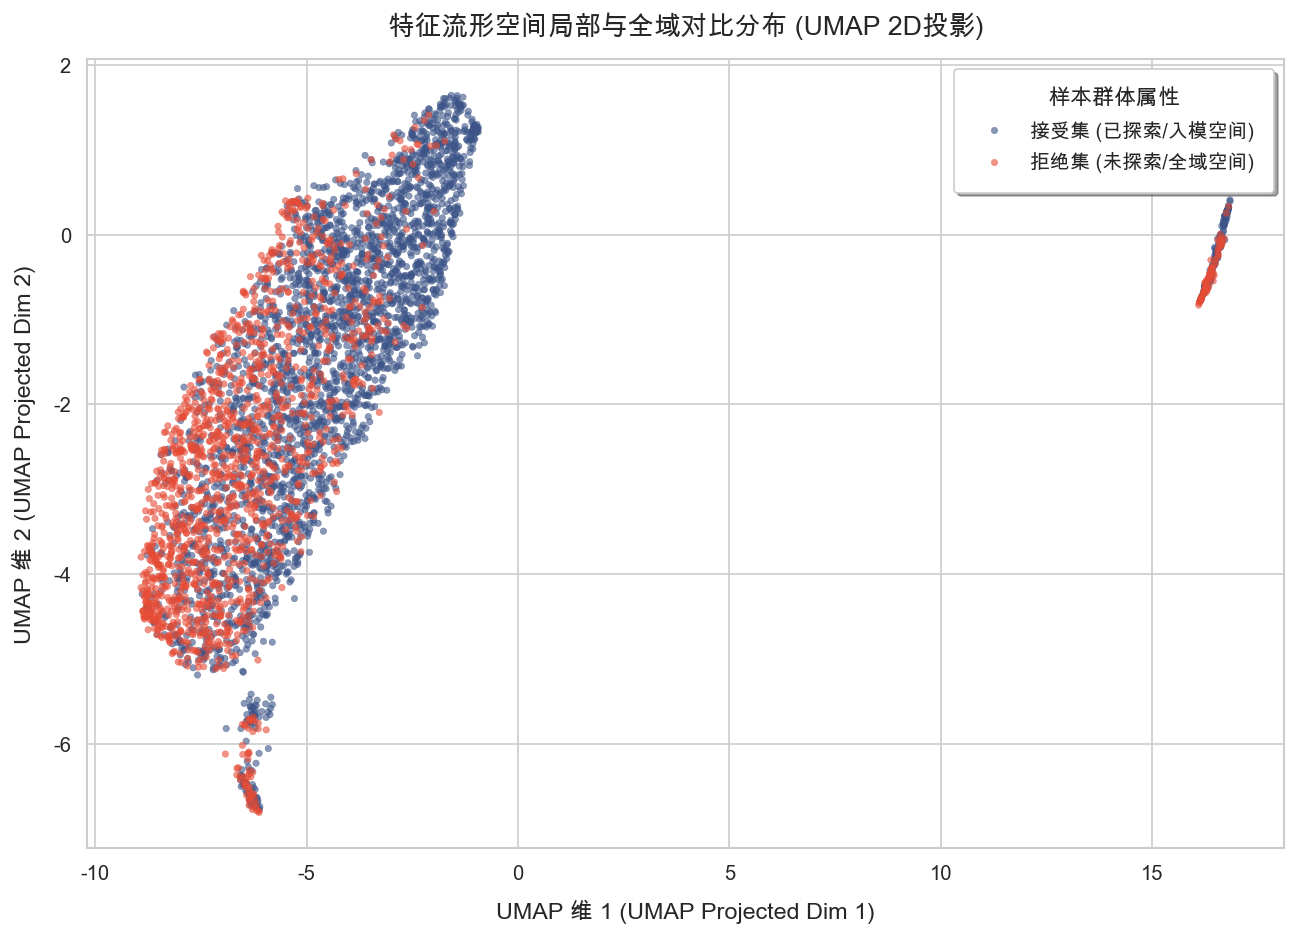

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import umap
import warnings

# 忽略收敛警告并设置匹配的中英文混合学术衬线字体
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False 

# 在 set_theme 时强制把全局字体设为 Arial Unicode MS
sns.set_theme(style="whitegrid", font="Arial Unicode MS", font_scale=1.1)


def plot_feature_manifold_umap(acc_path: str, rej_path: str, sample_size: int = 3000):
    """提取接受集与拒绝集特征进行 UMAP 流形变换并绘制 2D 散点图。

    通过对高维特征采用特征标准化与 UMAP 降维投影，在可视化层面展示出
    "接受集"（通过审批带标签的先验数据）仅仅是全域数据流形（Manifold）中的一个
    局部聚集态。旨在揭示"入模大门"导致的线性偏差以及表现庞大的未探索空间。

    Args:
        acc_path: 接受集提取的数据源文件路径（如 train_accepted_raw.xlsx）。
        rej_path: 拒绝集提取的数据源文件路径（如 train_rejected_raw.xlsx）。
        sample_size: 随机下采样数量。为防止散点过度堆积（重叠模糊），
                     设定单独从接受集与拒绝集分别抽取的样本数。默认 3000。

    Returns:
        None

    Raises:
        FileNotFoundError: 未找到传入的源文件路径时抛出异常。
    """
    print("正在加载数据 (使用 raw 原始特征构建全域观测面)...")
    df_acc = pd.read_excel(acc_path)
    df_rej = pd.read_excel(rej_path)
    
    # 提取以 'x' 开头的所有多维泛化特征
    feature_cols = [col for col in df_acc.columns if str(col).startswith('x')]
    print(f"提取到 {len(feature_cols)} 个泛化特征。")
    
    # 打上全局对比标签，便于映射画图配色
    df_acc['label_set'] = '接受集 (已探索/入模空间)'
    df_rej['label_set'] = '拒绝集 (未探索/全域空间)'
    
    print(f"开始降维准备：抽取各 {sample_size} 条独立样本...")
    # 固定随机数种子保持论文复现一致性
    df_acc_sample = df_acc.sample(n=min(sample_size, len(df_acc)), random_state=42)
    df_rej_sample = df_rej.sample(n=min(sample_size, len(df_rej)), random_state=42)
    
    df_concat = pd.concat([df_acc_sample, df_rej_sample], ignore_index=True)
    
    X = df_concat[feature_cols].values
    X = np.nan_to_num(X)  # 健壮性处理：将缺失或无穷大数据置零
    
    print("正在进行特征 StandardScaler 标准化...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print("启动 UMAP 流形学习隐层映射 (保留全局与局部结构，速度远快于 t-SNE)...")
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,    # 邻域大小：越大越关注全局结构，越小越关注局部聚类
        min_dist=0.1,      # 嵌入点最小距离：越小聚类越紧凑，越大分布越均匀
        metric='euclidean',
        random_state=42,
        verbose=True
    )
    X_2d = reducer.fit_transform(X_scaled)
    
    print("降维完成，开始绘制 2D 散点图...")
    # 把投影矩阵落库到 DataFrame
    df_plot = pd.DataFrame({
        'UMAP_Dim1': X_2d[:, 0],
        'UMAP_Dim2': X_2d[:, 1],
        '数据来源': df_concat['label_set']
    })
    
    plt.figure(figsize=(11, 8), dpi=120)
    
    # 色彩美学：接受集使用静谧的业务深蓝（#3C5488），拒绝集使用未知的警示红（#E64B35）
    palette = {'接受集 (已探索/入模空间)': '#3C5488', '拒绝集 (未探索/全域空间)': '#E64B35'}
    
    # 绘制高维投影二维散射图
    sns.scatterplot(
        data=df_plot, 
        x='UMAP_Dim1', 
        y='UMAP_Dim2', 
        hue='数据来源',
        palette=palette,
        alpha=0.6,
        s=15,             # 15是比较好的小散点尺寸，避免互相过度遮盖
        edgecolor=None    # 去掉轮廓线使得聚类边缘平滑细腻
    )
    
    # plt.title("特征流形空间局部与全域对比分布 (UMAP 2D投影)", fontsize=16, pad=15, fontweight='bold')
    plt.xlabel('UMAP 维 1 (UMAP Projected Dim 1)', fontsize=14, labelpad=10)
    plt.ylabel('UMAP 维 2 (UMAP Projected Dim 2)', fontsize=14, labelpad=10)
    
    # 调整图例
    plt.legend(title='样本群体属性', fontsize=12, frameon=True, shadow=True, borderpad=1, loc='upper right')
    
    plt.tight_layout()
    plt.show()

# 调用封装函数
plot_feature_manifold_umap(
    acc_path='../data/processed/train_accepted_raw.xlsx',
    rej_path='../data/processed/train_rejected_raw.xlsx',
    sample_size=3000
)

In [ ]:
def plot_feature_manifold_supervised_umap(acc_path: str, rej_path: str, sample_size: int = 3000):
    """Supervised UMAP：将标签信息注入降维过程，强制拉开接受集与拒绝集类间距离。"""
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.preprocessing import StandardScaler
    import umap
    import warnings
    warnings.filterwarnings('ignore')
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False
    sns.set_theme(style='whitegrid', font='Arial Unicode MS', font_scale=1.1)

    print('正在加载数据...')
    df_acc = pd.read_excel(acc_path)
    df_rej = pd.read_excel(rej_path)

    feature_cols = [col for col in df_acc.columns if str(col).startswith('x')]
    print(f'提取到 {len(feature_cols)} 个泛化特征。')

    df_acc['label_set'] = '接受集 (已探索/入模空间)'
    df_rej['label_set'] = '拒绝集 (未探索/全域空间)'

    df_acc_sample = df_acc.sample(n=min(sample_size, len(df_acc)), random_state=42)
    df_rej_sample = df_rej.sample(n=min(sample_size, len(df_rej)), random_state=42)
    df_concat = pd.concat([df_acc_sample, df_rej_sample], ignore_index=True)

    X = np.nan_to_num(df_concat[feature_cols].values)
    y = (df_concat['label_set'] == '接受集 (已探索/入模空间)').astype(int).values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print('启动 Supervised UMAP（标签引导降维，类间分离更显著）...')
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.1,
        target_metric='categorical',
        target_weight=0.5,   # 0~1，越大越依赖标签，类间分离越强
        metric='euclidean',
        random_state=42,
        verbose=True
    )
    X_2d = reducer.fit_transform(X_scaled, y=y)

    print('降维完成，开始绘制 2D 散点图...')
    df_plot = pd.DataFrame({
        'UMAP_Dim1': X_2d[:, 0],
        'UMAP_Dim2': X_2d[:, 1],
        '数据来源': df_concat['label_set']
    })

    plt.figure(figsize=(11, 8), dpi=120)
    palette = {'接受集 (已探索/入模空间)': '#3C5488', '拒绝集 (未探索/全域空间)': '#E64B35'}

    sns.scatterplot(
        data=df_plot,
        x='UMAP_Dim1',
        y='UMAP_Dim2',
        hue='数据来源',
        palette=palette,
        alpha=0.6,
        s=15,
        edgecolor=None
    )

    plt.title('特征流形空间局部与全域对比分布 (Supervised UMAP 2D投影)', fontsize=16, pad=15, fontweight='bold')
    plt.xlabel('UMAP 维 1 (Supervised UMAP Dim 1)', fontsize=14, labelpad=10)
    plt.ylabel('UMAP 维 2 (Supervised UMAP Dim 2)', fontsize=14, labelpad=10)
    plt.legend(title='样本群体属性', fontsize=12, frameon=True, shadow=True, borderpad=1, loc='upper right')
    plt.tight_layout()
    plt.show()


# 调用 Supervised UMAP
plot_feature_manifold_supervised_umap(
    acc_path='../data/processed/train_accepted_raw.xlsx',
    rej_path='../data/processed/train_rejected_raw.xlsx',
    sample_size=3000
)

正在加载数据...
原始特征数: 123
随机森林特征重要性筛选中...
筛选后特征数: 22 / 123
启动 UMAP 降维（基于高判别力特征子集）...
UMAP(min_dist=0.05, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Mar 24 20:43:29 2026 Construct fuzzy simplicial set
Tue Mar 24 20:43:29 2026 Finding Nearest Neighbors
Tue Mar 24 20:43:29 2026 Building RP forest with 8 trees
Tue Mar 24 20:43:29 2026 NN descent for 12 iterations
	 1  /  12
	 2  /  12
	 3  /  12
	Stopping threshold met -- exiting after 3 iterations
Tue Mar 24 20:43:30 2026 Finished Nearest Neighbor Search
Tue Mar 24 20:43:30 2026 Construct embedding


Epochs completed:   3%| ▎          14/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  14%| █▎         68/500 [00:00]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  92%| █████████▏ 461/500 [00:05]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:05]


Tue Mar 24 20:43:35 2026 Finished embedding
降维完成，开始绘制 2D 散点图...


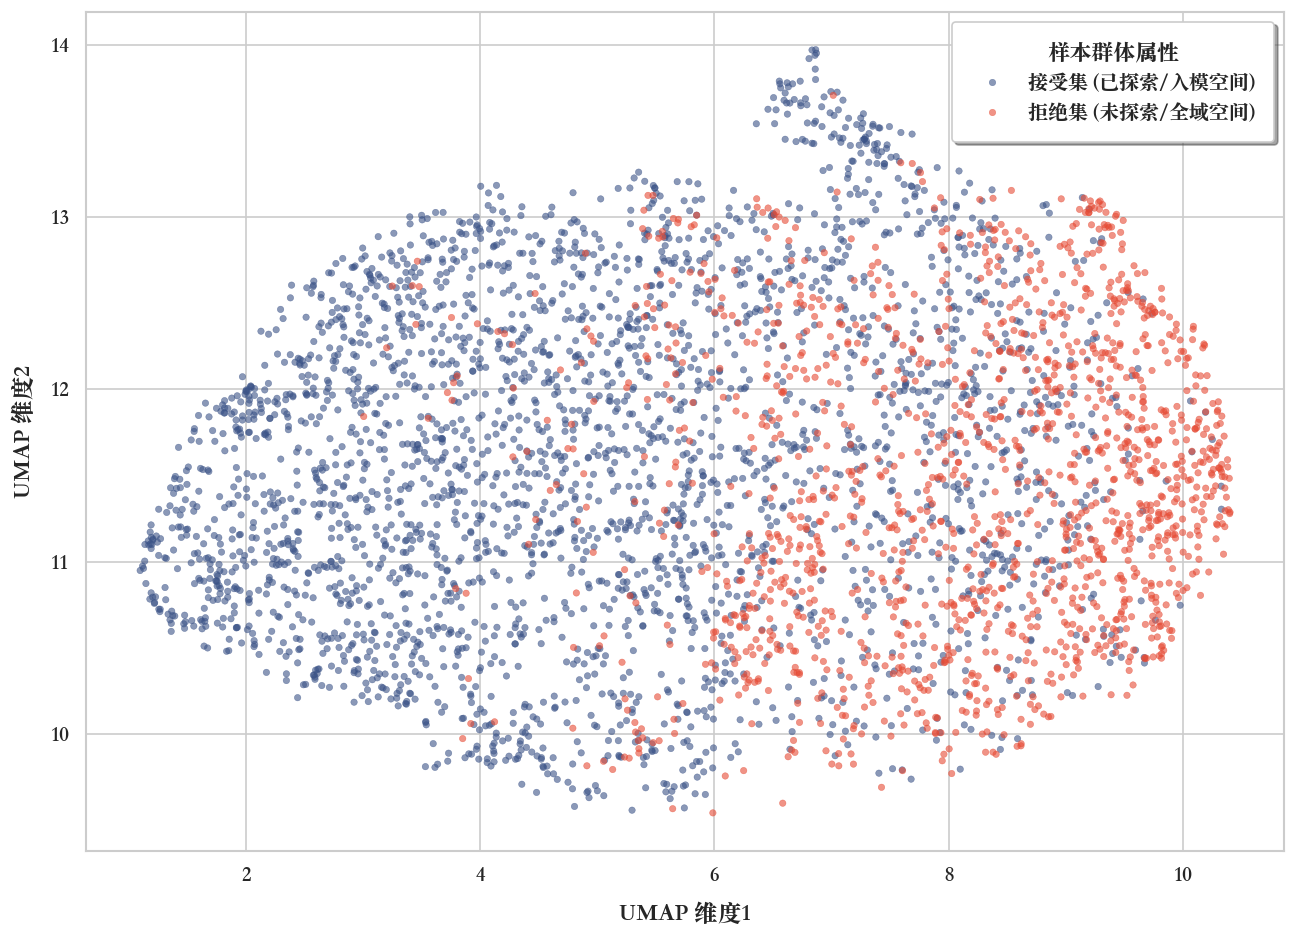

In [12]:
def plot_feature_manifold_selected_umap(acc_path: str, rej_path: str, sample_size: int = 3000):
    """先用随机森林筛选判别力最强的特征，再用 UMAP 降维可视化。"""
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.feature_selection import SelectFromModel
    import umap
    import warnings
    warnings.filterwarnings('ignore')
    sns.set_theme(style='whitegrid', font_scale=1.1)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
    plt.rcParams['font.sans-serif'] = ['Songti SC', 'STSong', 'SimSun', 'Times New Roman']
    plt.rcParams['axes.unicode_minus'] = False

    print('正在加载数据...')
    df_acc = pd.read_excel(acc_path)
    df_rej = pd.read_excel(rej_path)

    feature_cols = [col for col in df_acc.columns if str(col).startswith('x')]
    print(f'原始特征数: {len(feature_cols)}')

    df_acc['label_set'] = '接受集 (已探索/入模空间)'
    df_rej['label_set'] = '拒绝集 (未探索/全域空间)'

    df_acc_sample = df_acc.sample(n=min(sample_size, len(df_acc)), random_state=42)
    df_rej_sample = df_rej.sample(n=min(sample_size, len(df_rej)), random_state=42)
    df_concat = pd.concat([df_acc_sample, df_rej_sample], ignore_index=True)

    X = np.nan_to_num(df_concat[feature_cols].values)
    y = (df_concat['label_set'] == '接受集 (已探索/入模空间)').astype(int).values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print('随机森林特征重要性筛选中...')
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_scaled, y)

    selector = SelectFromModel(clf, threshold='mean', prefit=True)
    X_selected = selector.transform(X_scaled)
    print(f'筛选后特征数: {X_selected.shape[1]} / {X_scaled.shape[1]}')

    print('启动 UMAP 降维（基于高判别力特征子集）...')
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.05,
        metric='euclidean',
        random_state=42,
        verbose=True
    )
    X_2d = reducer.fit_transform(X_selected)

    print('降维完成，开始绘制 2D 散点图...')
    df_plot = pd.DataFrame({
        'UMAP_Dim1': X_2d[:, 0],
        'UMAP_Dim2': X_2d[:, 1],
        '数据来源': df_concat['label_set']
    })

    plt.figure(figsize=(11, 8), dpi=120)
    palette = {'接受集 (已探索/入模空间)': '#3C5488', '拒绝集 (未探索/全域空间)': '#E64B35'}

    sns.scatterplot(
        data=df_plot,
        x='UMAP_Dim1',
        y='UMAP_Dim2',
        hue='数据来源',
        palette=palette,
        alpha=0.6,
        s=15,
        edgecolor=None
    )

    # plt.title('特征流形空间局部与全域对比分布', fontsize=16, pad=15, fontweight='bold')
    plt.xlabel('UMAP 维度1', fontsize=14, labelpad=10)
    plt.ylabel('UMAP 维度2', fontsize=14, labelpad=10)
    plt.legend(title='样本群体属性', fontsize=12, frameon=True, shadow=True, borderpad=1, loc='upper right')
    plt.tight_layout()
    plt.show()


# 调用特征筛选 + UMAP
plot_feature_manifold_selected_umap(
    acc_path='../data/processed/train_accepted_raw.xlsx',
    rej_path='../data/processed/train_rejected_raw.xlsx',
    sample_size=3000
)